<a href="https://colab.research.google.com/github/amathie5/PPS-Project-/blob/main/part_3_valentine%2BPT_review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import norm as normSci
import numpy as np
import pandas as pd
from google.colab import files
import io
from pylab import  *


In [ ]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_1 = pd.read_csv(io.BytesIO(uploaded[filename]))

# View the first few rows
df_1.head()

Saving Demand_data.csv to Demand_data.csv


,Day,3235 Movement (units),Oystersteel Case (units),Sapphire Crystal (units),Jubilee Bracelet (units),Lubricant Oil (grams),Diamond Marker (units),Gold Crown (units)
0,1,15,12,13,8,147,46,6
1,2,11,14,9,8,106,49,4
2,3,16,10,12,9,154,48,8
3,4,12,7,8,10,80,48,7
4,5,16,6,14,8,176,44,4


In [ ]:
df_1.describe()

,Day,3235 Movement (units),Oystersteel Case (units),Sapphire Crystal (units),Jubilee Bracelet (units),Lubricant Oil (grams),Diamond Marker (units),Gold Crown (units)
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,183.000000,14.260274,15.178082,14.210959,8.016438,150.723288,47.805479,8.005479
std,105.510663,3.561190,4.281132,3.587507,0.994354,41.180021,5.093950,3.032783
min,1.000000,5.000000,4.000000,4.000000,5.000000,40.000000,35.000000,0.000000
25%,92.000000,12.000000,12.000000,12.000000,7.000000,122.000000,44.000000,6.000000
50%,183.000000,14.000000,15.000000,14.000000,8.000000,147.000000,48.000000,8.000000
75%,274.000000,17.000000,18.000000,17.000000,9.000000,175.000000,51.000000,10.000000
max,365.000000,25.000000,29.000000,25.000000,12.000000,298.000000,63.000000,17.000000


In [ ]:
components = df_1.columns[1:]

mean_demand = df_1[components].mean()
std_demand = df_1[components].std()

summary = pd.DataFrame({
"Mean Demand": mean_demand,
"Std Demand": std_demand
})

summary

,Mean Demand,Std Demand
3235 Movement (units),14.260274,3.561190
Oystersteel Case (units),15.178082,4.281132
Sapphire Crystal (units),14.210959,3.587507
Jubilee Bracelet (units),8.016438,0.994354
Lubricant Oil (grams),150.723288,41.180021
Diamond Marker (units),47.805479,5.093950
Gold Crown (units),8.005479,3.032783


In [ ]:
annual_demand = df_1[components].sum()

summary["Annual Demand"] = annual_demand

summary

,Mean Demand,Std Demand,Annual Demand
3235 Movement (units),14.260274,3.561190,5205
Oystersteel Case (units),15.178082,4.281132,5540
Sapphire Crystal (units),14.210959,3.587507,5187
Jubilee Bracelet (units),8.016438,0.994354,2926
Lubricant Oil (grams),150.723288,41.180021,55014
Diamond Marker (units),47.805479,5.093950,17449
Gold Crown (units),8.005479,3.032783,2922


In [ ]:
#création du tableau donné dans pdf
inventory_params = pd.DataFrame({
"Component":[
"3235 Movement (units)",
"Oystersteel Case (units)",
"Sapphire Crystal (units)",
"Jubilee Bracelet (units)",
"Lubricant Oil (grams)",
"Diamond Marker (units)",
"Gold Crown (units)"
],

"Lead Time":[60,45,30,35,14,21,40],

"Holding Cost":[1200,400,200,220,50,900,350],

"Ordering Cost":[9000,7000,4000,3500,1000,6000,5000]
})

In [ ]:
inventory_data = inventory_params.merge(
summary,
left_on="Component",
right_index=True
)

inventory_data

,Component,Lead Time,Holding Cost,Ordering Cost,Mean Demand,Std Demand,Annual Demand
0,3235 Movement (units),60,1200,9000,14.260274,3.561190,5205
1,Oystersteel Case (units),45,400,7000,15.178082,4.281132,5540
2,Sapphire Crystal (units),30,200,4000,14.210959,3.587507,5187
3,Jubilee Bracelet (units),35,220,3500,8.016438,0.994354,2926
4,Lubricant Oil (grams),14,50,1000,150.723288,41.180021,55014
5,Diamond Marker (units),21,900,6000,47.805479,5.093950,17449
6,Gold Crown (units),40,350,5000,8.005479,3.032783,2922


In [ ]:
#EOQ
inventory_data["EOQ"] = np.sqrt(
(2 * inventory_data["Annual Demand"] * inventory_data["Ordering Cost"])
/ inventory_data["Holding Cost"]
)

In [ ]:
#Reoder point R = demand * lead time
inventory_data["Reorder Point"] = (
inventory_data["Mean Demand"] * inventory_data["Lead Time"]
)


In [ ]:
#Safety Stock service level 95%
z = 1.65

inventory_data["Safety Stock"] = (
z * inventory_data["Std Demand"] * np.sqrt(inventory_data["Lead Time"])
)

In [ ]:
inventory_data

,Component,Lead Time,Holding Cost,Ordering Cost,Mean Demand,Std Demand,Annual Demand,EOQ,Reorder Point,Safety Stock
0,3235 Movement (units),60,1200,9000,14.260274,3.561190,5205,279.419040,855.616438,45.515012
1,Oystersteel Case (units),45,400,7000,15.178082,4.281132,5540,440.340777,683.013699,47.385864
2,Sapphire Crystal (units),30,200,4000,14.210959,3.587507,5187,455.499726,426.328767,32.421819
3,Jubilee Bracelet (units),35,220,3500,8.016438,0.994354,2926,305.122926,280.575342,9.706419
4,Lubricant Oil (grams),14,50,1000,150.723288,41.180021,55014,1483.428461,2110.126027,254.234522
5,Diamond Marker (units),21,900,6000,47.805479,5.093950,17449,482.341511,1003.915068,38.516625
6,Gold Crown (units),40,350,5000,8.005479,3.032783,2922,288.938946,320.219178,31.648655


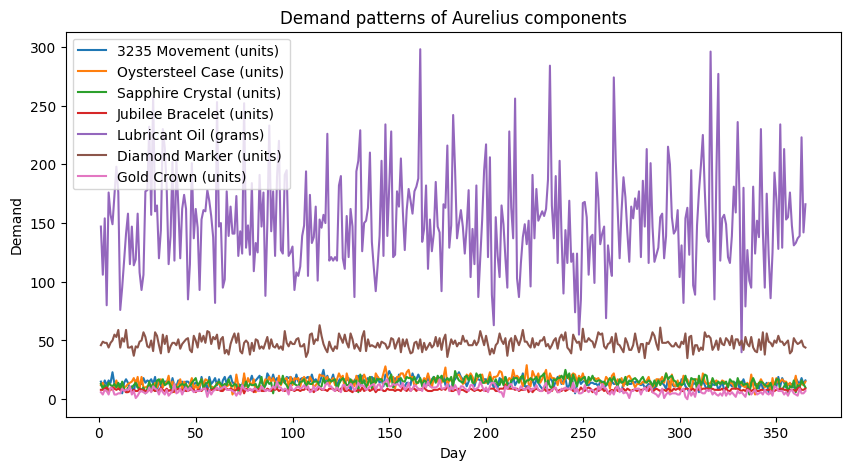

In [ ]:
df_1.plot(x="Day", figsize=(10,5))

plt.title("Demand patterns of Aurelius components")
plt.ylabel("Demand")
plt.show()

In [ ]:
component = "3235 Movement (units)"

D = inventory_data.loc[inventory_data["Component"] == component, "Annual Demand"].values[0]
S = inventory_data.loc[inventory_data["Component"] == component, "Ordering Cost"].values[0]

In [ ]:
holding_values = np.linspace(200,2000,20)

EOQ_values = np.sqrt((2 * D * S) / holding_values)

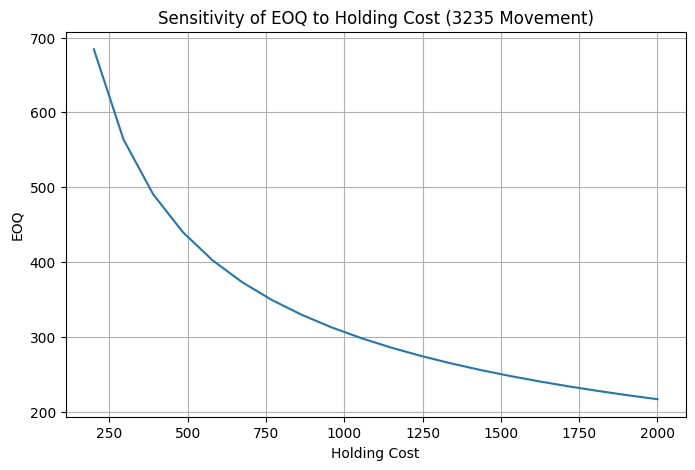

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(holding_values, EOQ_values)

plt.xlabel("Holding Cost")
plt.ylabel("EOQ")
plt.title("Sensitivity of EOQ to Holding Cost (3235 Movement)")

plt.grid(True)

plt.show()

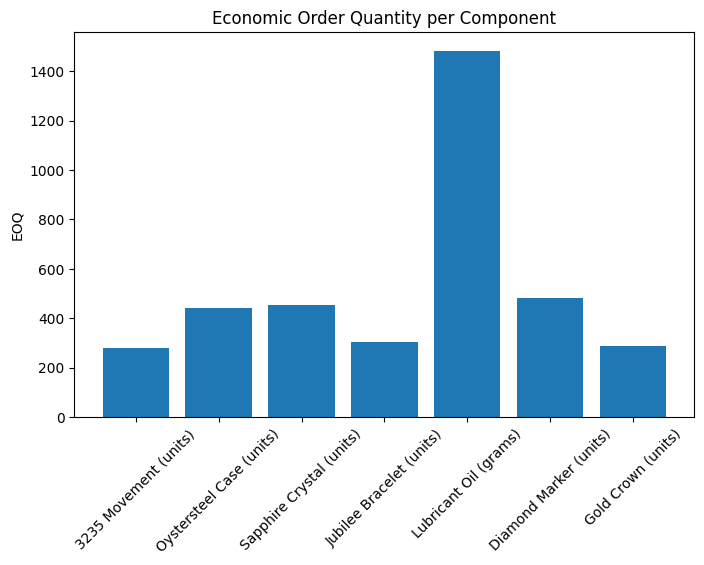

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(inventory_data["Component"], inventory_data["EOQ"])

plt.xticks(rotation=45)
plt.ylabel("EOQ")
plt.title("Economic Order Quantity per Component")

plt.show()

PT systeme (periodic review) prendre en compte shelf life? pas utilisé


In [ ]:
#useful parameters for the model:

# Lead time (tau)
tau = inventory_params["Lead Time"]

# Holding cost (h)
h = inventory_params["Holding Cost"]

# Ordering cost (K)
K = inventory_params["Ordering Cost"]

# sfaety levl
alpha= 0.95 #fixé random
tau.index = components
h.index = components
K.index = components

mean_demand = df_1[components].mean()
std_demand = df_1[components].std()
annual_demand = df_1[components].sum()



In [ ]:
def calculate_optimal_T(annual_demand, K, h, working_days, working_weeks):

    EOQ = np.sqrt((2 * annual_demand * K) / h)

    total_working_days = working_days * working_weeks

    T_days = EOQ / (annual_demand / total_working_days)

    return T_days

In [ ]:
from scipy.stats import norm

def calculate_order_up_to_level(mean_demand, std_demand, T, tau, alpha):

    protection_interval = T + tau

    mu_protection = mean_demand * protection_interval
    sigma_protection = std_demand * np.sqrt(protection_interval)

    S = mu_protection + norm.ppf(alpha) * sigma_protection

    return S

!!!!!!a definir ou mettre une analyse de sensibilité peu satisfait des working days!!!!!!

In [ ]:
# Working calendar
working_days = 365  # jours travaillés par semaine
working_weeks = 1   # semaines travaillées par an


In [ ]:
T_optimal = calculate_optimal_T(annual_demand, K, h, working_days, working_weeks)

S_optimal = calculate_order_up_to_level(
    mean_demand,
    std_demand,
    T_optimal,
    tau,
    alpha
)

print("Optimal review period T* (days):") #review interval
print(T_optimal)

print("\nOrder-up-to level S*:") #target inventory
print(S_optimal)

Optimal review period T* (days):
3235 Movement (units)       19.594227
Oystersteel Case (units)    29.011622
Sapphire Crystal (units)    32.052709
Jubilee Bracelet (units)    38.062156
Lubricant Oil (grams)        9.842065
Diamond Marker (units)      10.089670
Gold Crown (units)          36.092647
dtype: float64

Order-up-to level S*:
3235 Movement (units)       1187.294724
Oystersteel Case (units)    1183.935389
Sapphire Crystal (units)     928.312165
Jubilee Bracelet (units)     599.678506
Lubricant Oil (grams)       3924.293752
Diamond Marker (units)      1532.975193
Gold Crown (units)           652.673218
dtype: float64


inventory position graph per components

In [ ]:
df_1.columns

Index(['Day', '3235 Movement (units)', 'Oystersteel Case (units)',
       'Sapphire Crystal (units)', 'Jubilee Bracelet (units)',
       'Lubricant Oil (grams)', 'Diamond Marker (units)',
       'Gold Crown (units)'],
      dtype='object')

/tmp/ipykernel_417/3928401311.py:32: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  on_order = sum(qty for arrival, qty in pending_orders)


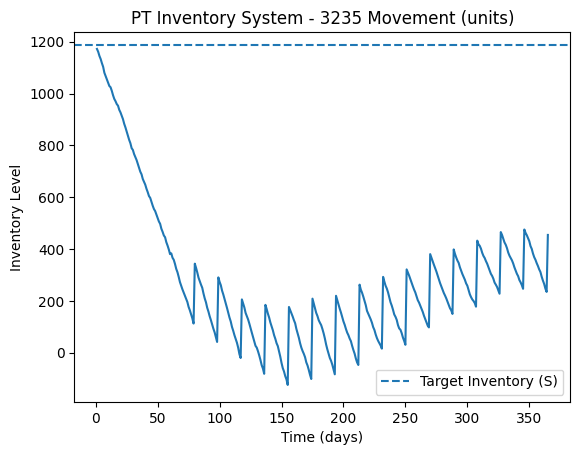

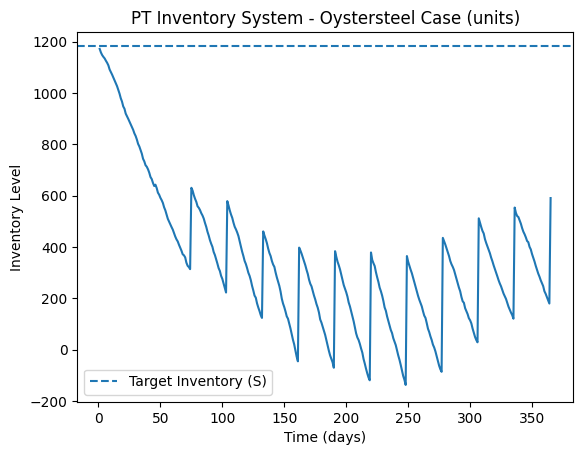

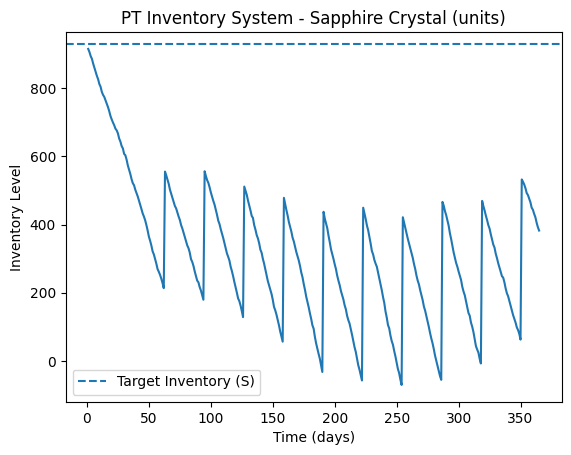

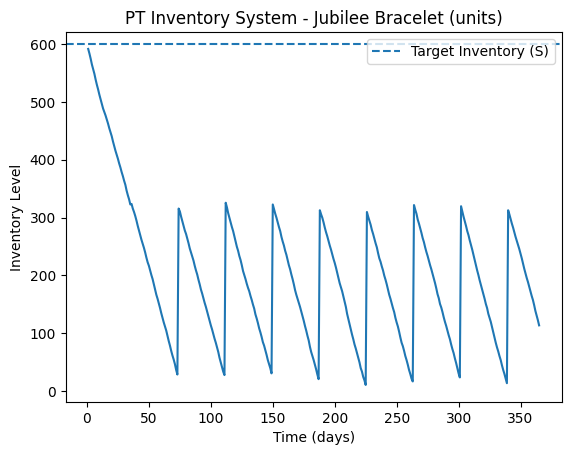

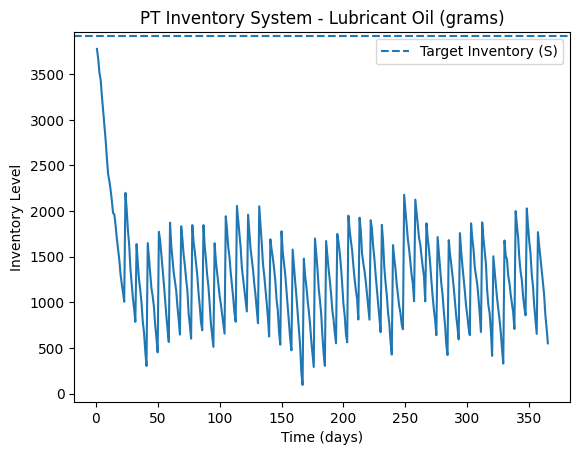

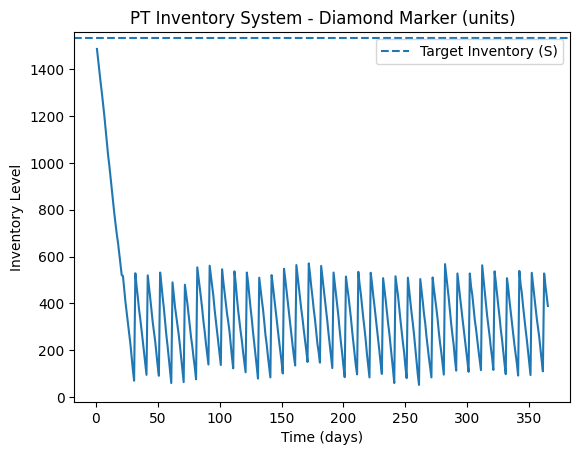

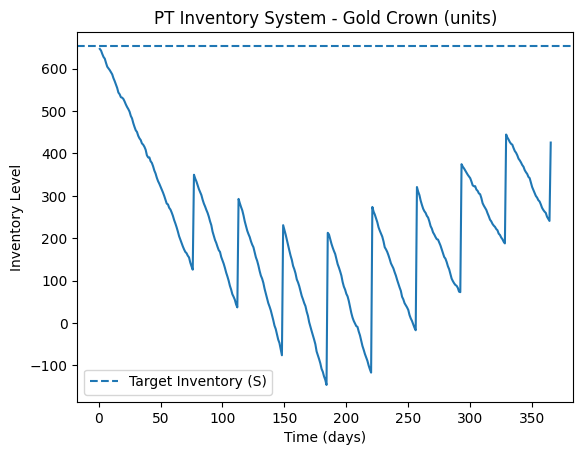

In [ ]:
import matplotlib.pyplot as plt

time = df_1["Day"]

for comp in components:

    S = S_optimal[comp]
    T = int(T_optimal[comp])
    lead = int(tau[comp])

    current_inventory = S
    inventory = []

    pending_orders = []

    for t, demand in enumerate(df_1[comp]):

        # arrivée des commandes
        for order in pending_orders:
            if order[0] == t:
                current_inventory += order[1]

        pending_orders = [o for o in pending_orders if o[0] != t]

        # demande réelle
        current_inventory -= demand

        # review périodique
        if t % T == 0:

            # quantité déjà commandée
            on_order = sum(qty for arrival, qty in pending_orders)

            # inventory position
            inventory_position = current_inventory + on_order

            order_qty = S - inventory_position

            if order_qty > 0:
                arrival_day = t + lead
                pending_orders.append((arrival_day, order_qty))

        inventory.append(current_inventory)

    plt.figure()
    plt.plot(time, inventory)

    plt.xlabel("Time (days)")
    plt.ylabel("Inventory Level")
    plt.title(f"PT Inventory System - {comp}")

    plt.axhline(S, linestyle="--", label="Target Inventory (S)")
    plt.legend()

    plt.show()

The periodic review (P,T) inventory system is not well suited for this case because the lead times of several components are significantly longer than the optimal review period. For example, the review period is approximately 20 days, while the lead time for some components reaches up to 60 days. This means that multiple orders are placed before the first one even arrives, creating overlapping orders in the pipeline. As a result, the inventory level becomes unstable and oscillates significantly, which reduces the efficiency of inventory control. In contrast, a continuous review (Q,R) system would be more appropriate because it triggers replenishment only when the inventory reaches the reorder point, allowing for better control of stock levels despite long lead times.
